In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# jax
import jax.numpy as jnp
import time

import sys
import os

path_ = os.path.abspath(os.path.join('..', 'utils'))
if path_ not in sys.path:
    sys.path.append(path_)

path_ = os.path.abspath(os.path.join('..', 'models'))
if path_ not in sys.path:
    sys.path.append(path_)
    
path_ = os.path.abspath(os.path.join('..', 'utils_training'))
if path_ not in sys.path:
    sys.path.append(path_)

In [5]:
import importlib

def reload_module(module_name, class_name):
    module = importlib.import_module(module_name)
    importlib.reload(module)
    return getattr(module, class_name)

In [6]:
from datetime import datetime, timedelta

start_date = '2015-01-10'
def generate_dates(start_date, sequence_len = 5, frequency = 2):
    start_date = datetime.strptime(start_date, '%Y-%m-%d')
    date_sequences = [start_date + timedelta(days=i*frequency) for i in range(sequence_len)]
    date_sequences_str = [date.strftime('%Y-%m-%d') for date in date_sequences]
    return date_sequences_str

---
# Single Model

In [42]:
ExperimentRunner = reload_module('optimize_pyomo_rl', 'ExperimentRunner')

tol = 1e-6
start_date = '2015-01-15'
extra_input = {}
extra_input['params_data'] = {'file_path': '../00_data/df_train.csv', 'start_date': start_date, 
                'n_points': 600, 'split': 360, 'n_days': 1, 'm': 1, 
                'prev_hour': False, 'prev_week': True, 'prev_year': True,
                'spacing': 'gauss_radau',
                'encoding': {'settlement_date': 't', 'temperature': 'var1', 'hour': 'var2', 'nd': 'y'},}

extra_input['params_sequence'] = {'sequence_len': 10, 'frequency': 5}
extra_input['params_model'] = {'layer_sizes': [7, 32, 1], 'penalty': 1e-7}
extra_input['params_solver'] = { "tol" : tol, 
                         "halt_on_ampl_error" : 'yes', "print_level": 1, "max_iter": 500, 'warm_start_init_point': 'yes'}

extra_input['plot_odeint'] = True

runner = ExperimentRunner(start_date, 'default', extra_input)
runner.run()

Generating default parameters for ode solver
Running iteration 1 with parameters: 1
{'layer_sizes': [7, 32, 1], 'penalty': 1e-07, 'w_init_method': 'xavier'}
Spacing type: gauss_radau
w init method: xavier
current_16_08
y
Ipopt 3.14.16: tol=1e-06
halt_on_ampl_error=yes
print_level=1
max_iter=500
warm_start_init_point=yes


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Ipopt 3.14.16: print_level=1


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more info

In [43]:
single_model_results = runner.results_full
df_single = pd.DataFrame(single_model_results).T
df_single.reset_index(inplace=True)
df_single.rename(columns={'level_0': 'regularization'}, inplace=True)
df_single.drop(columns=['level_1', 'result', 'mse_odeint', 'mse_odeint_test'], inplace=True)
df_single

,regularization,times_elapsed,mse_coll_ode,mse_coll_ode_test
0,1,120.47177,0.016155,3.720037
1,1,93.786837,0.262381,0.185062
2,1,107.043143,0.072189,2.678499
3,1,111.492611,1.220539,1.031879
4,1,108.334501,0.10757,0.112877
5,1,107.694032,0.023403,0.213725
6,1,103.307195,0.010706,4.020647
7,1,109.666543,0.051984,0.832626
8,1,106.902967,0.038983,0.200935
9,1,105.96977,0.555537,1.320989


---
# ADMM

In [44]:
# Constants and Configurations
PENALTY = 1e-5
LAYER_SIZES = [7, 32, 1]
tol = 1e-4
params = {
    "tol": tol,
    "dual_inf_tol": tol,
    "compl_inf_tol": tol,
    "constr_viol_tol": tol,
    "halt_on_ampl_error": 'yes',
    "print_level": 5,
    "max_iter": 500
}
file_path = '../00_data/df_train.csv'
encoding = {'settlement_date': 't', 'temperature': 'var1', 'hour': 'var2', 'nd': 'y'}

date_sequences_str = generate_dates(start_date, sequence_len = 10, frequency = 5)

def prepare_data(start_date, file_path, encoding):
    data_preprocessor = reload_module('preprocess', 'DataPreprocessor')(
        file_path, start_date=start_date, number_of_points = 360, n_days = 1, m = 1, 
        prev_hour = False, prev_week = True, prev_year = True,
        feature_encoding=encoding, split=180, spacing = 'gauss_radau', smooth = False)
    data_subsample = data_preprocessor.load_data()
    return data_preprocessor.preprocess_data(data_subsample), str(data_preprocessor.end_date), data_preprocessor.derivative_matrix()

In [45]:
DataPreprocessor = reload_module('preprocess', 'DataPreprocessor')
NeuralODEPyomoADMM = reload_module('nn_pyomo_admm', 'NeuralODEPyomoADMM')

results = {}
for start_date in date_sequences_str:
    (df_train_1, df_test_1), end_date, (D_1, _) = prepare_data(start_date, file_path, encoding)
    (df_train_2, df_test_2), _, (D_2, D_2_test) = prepare_data(end_date, file_path, encoding)

    # dhift time
    shift = df_train_2['t'].max() - df_train_2['t'].min()
    df_train_2['t'] += shift
    df_test_2['t'] += shift

    # concatenate data
    ys = np.concatenate([df_train_1['y'].values[:, None], df_train_2['y'].values[:, None]], axis = 0)
    ts = np.concatenate([df_train_1['t'], df_train_2['t']])
    Xs = np.concatenate([df_train_1.drop(columns=['y', 't']).values, df_train_2.drop(columns=['y', 't']).values], axis=0)
    Ds = [D_1, D_2]

    # Model and solve
    ode_model = NeuralODEPyomoADMM(
        y_observed=ys, t=ts, first_derivative_matrix=Ds,
        extra_input=Xs, y_init=ys, layer_sizes=LAYER_SIZES,
        act_func="tanh", penalty_lambda_reg=PENALTY, rho=5.0,
        time_invariant=True, w_init_method='xavier', params=params,
        test_data = {'t': df_test_2['t'], 'y': df_test_2['y'], 'D': D_2_test, 'X': df_test_2.drop(columns=['y', 't']).values}
    )
    
    result = ode_model.admm_solve(iterations = 50, tol_primal=1e-3, record=True)
    results[start_date] = result

# prepare test data
t_test = df_test_2['t']
y_test = df_test_2['y']
X_test = df_test_2.drop(columns=['y', 't']).values

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x106539c70>>
Traceback (most recent call last):
  File "/Users/mariiashapo/anaconda3/envs/collocation_env/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


----------------------------------------------------------------------------------------------------
ADMM Iteration 1/50; 0
----------------------------------------------------------------------------------------------------
Ipopt 3.14.16: tol=0.0001
dual_inf_tol=0.0001
compl_inf_tol=0.0001
constr_viol_tol=0.0001
halt_on_ampl_error=yes
print_level=5
max_iter=500


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.7.1.

Number of nonzeros in equality constraint Jacobian...:    83951
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.......

In [ ]:
df = pd.DataFrame(results).T
df

,primal_residual,mae_collocation,mse_collocation,mae_diffrax,mse_diffrax,iter,time_elapsed,mse_collocation_test
2015-01-15,"[226.15632673357078, 224.59504251528935, 6.854...",[],"[1.089742018253799, 1.0697906202905054, 0.5067...",[],"[1.0937030889755401, 1.0714533817348462, 0.502...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[14.973712921142578, 16.62470579147339, 19.045...","[3.0393373373319386, 3.060186482981829, 3.1149..."
2015-01-20,"[240.25345279480052, 239.23020121231733, 5.003...",[],"[4.530262543598915, 4.758996238236106, 2.86553...",[],"[27.48029934580463, 30.134071564111874, 54.581...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[21.452844858169556, 22.410218000411987, 24.48...","[1.095476146858092, 1.1368211711033538, 12.819..."
2015-01-25,"[225.74527659700863, 225.73510049086377, 5.374...",[],"[6.730579501142365, 6.71865432699052, 7.246612...",[],"[384.8964742227472, 370.229843482461, 159.1462...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[23.443664073944092, 24.53070902824402, 28.417...","[8.065339516050981, 7.3432498433284685, 8.0950..."
2015-01-30,"[211.82587879613234, 211.38739670625228, 9.838...",[],"[4.207354419048367, 3.708135379069386, 1.71857...",[],"[4.177583849780376, 3.8303195858555763, 1.7313...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[22.622432947158813, 23.79847764968872, 26.563...","[15.056932906927338, 14.91577600872558, 15.566..."
2015-02-04,"[207.78963782851903, 207.90188799372655, 5.612...",[],"[1.0308077029043525, 1.023805446522164, 1.0535...",[],"[1.3142976640676627, 1.3216560553497338, 1.347...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[23.628164529800415, 24.961156606674194, 29.78...","[1.4954821160789367, 1.4687937950361287, 3.328..."
2015-02-09,"[231.19387342907402, 229.85313187834052, 4.469...",[],"[5.830425088854076, 5.967776519284012, 3.47761...",[],"[204.4869287033863, 199.21178722895937, 196.38...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[19.9810471534729, 22.211997032165527, 24.7646...","[12.604409846162964, 12.22001521670556, 11.385..."
2015-02-14,"[226.85275434565767, 223.3722385561812, 7.2057...",[],"[4.067062560152192, 4.566351761273, 1.41997407...",[],"[42.13566745046293, 57.87322229170957, 1.39437...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[30.862467050552368, 35.81706476211548, 39.665...","[11.693084830446407, 8.886831405003527, 14.985..."
2015-02-19,"[223.40009833724002, 224.5507194153399, 4.1455...",[],"[5.936315490741112, 2.0943294706774775, 0.8641...",[],"[5.898123515350961, 2.0646654806169686, 0.9370...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[64.44712018966675, 70.82411932945251, 76.4126...","[7.575292810461226, 4.566226693556102, 6.10119..."
2015-02-24,"[247.40779291138898, 247.40779416857265, 5.204...",[],"[4.447395635999077, 4.447395819676579, 3.54939...",[],"[26.189003051378087, 27.192697350016154, 18.97...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[34.31887102127075, 35.49815058708191, 43.4843...","[6.280861666056271, 6.280861365534705, 4.17405..."
2015-03-01,"[201.81802967294857, 201.81801245015745, 5.935...",[],"[2.6096516913133723, 2.6096624844103657, 3.104...",[],"[74.37776061149793, 76.86690797243658, 49.7986...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[30.50918412208557, 31.391425848007202, 36.854...","[9.154209119148463, 9.154209021393216, 8.34882..."


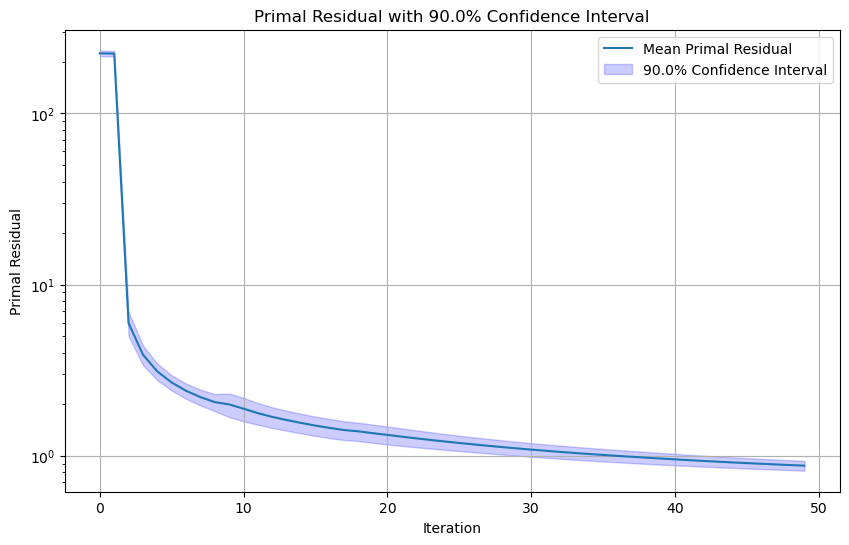

In [34]:
from scipy.stats import t

# Collect all data into a list of dictionaries
data_list = []
for i in range(df.shape[0]):
    mse = df['primal_residual'].iloc[i]
    iters = df['iter'].iloc[i]
    run_label = f'start date = {df.index[i]}'
    data_list.extend([{'iter': it, 'primal_residual': mse_val, 'run': run_label} for it, mse_val in zip(iters, mse)])
    
# Create a new DataFrame from the list
data_df = pd.DataFrame(data_list)

# Group by 'iter' to compute mean and standard deviation
grouped = data_df.groupby('iter')
mean_mse = grouped['primal_residual'].mean()
std_mse = grouped['primal_residual'].std()
n = grouped['primal_residual'].count()

# Compute standard error and confidence intervals
confidence = 0.9
dfree = n - 1
alpha = 1 - confidence
t_crit = t.ppf(1 - alpha/2, dfree)
se_mse = std_mse / np.sqrt(n)
margin_of_error = t_crit * se_mse
upper_bound = mean_mse + margin_of_error
lower_bound = mean_mse - margin_of_error


# Plot the mean with confidence intervals
plt.figure(figsize=(10, 6))
plt.plot(mean_mse.index, mean_mse.values, label='Mean Primal Residual')
plt.fill_between(mean_mse.index, lower_bound, upper_bound, color='blue', alpha=0.2, label=f'{confidence*100}% Confidence Interval')

plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Primal Residual')
plt.title(f'Primal Residual with {confidence*100}% Confidence Interval')
plt.legend()
plt.grid()
plt.show()


In [35]:
single_model_results = runner.results_full
df_single = pd.DataFrame(single_model_results).T
df_single.reset_index(inplace=True)
df_single.rename(columns={'level_0': 'regularization'}, inplace=True)
df_single.drop(columns=['level_1', 'result', 'mse_odeint', 'mse_odeint_test'], inplace=True)
df_single

,regularization,times_elapsed,mse_coll_ode,mse_coll_ode_test
0,1,23.561444,0.134158,0.177751
1,1,23.098089,0.054201,0.209077
2,1,32.044839,0.173609,5.160382
3,1,27.580111,0.085784,0.331371
4,1,34.042045,0.12693,0.072831
5,1,20.758266,0.061923,0.225175
6,1,27.025415,0.03047,0.58377
7,1,25.839145,0.051093,0.585005
8,1,26.230149,0.087269,1.874671
9,1,24.379304,0.222128,0.345


In [36]:
from scipy.stats import t

# Collect all data into a list of dictionaries
data_list = []
for i in range(df.shape[0]):
    mse = df['mse_collocation'].iloc[i]
    iters = df['iter'].iloc[i]
    run_label = f'start date = {df.index[i]}'
    data_list.extend([{'iter': it, 'mse_collocation': mse_val, 'run': run_label} for it, mse_val in zip(iters, mse)])
    
# Create a new DataFrame from the list
data_df = pd.DataFrame(data_list)

# Group by 'iter' to compute mean and standard deviation
grouped = data_df.groupby('iter')
mean_mse = grouped['mse_collocation'].mean()
std_mse = grouped['mse_collocation'].std()
n = grouped['mse_collocation'].count()

# Compute standard error and confidence intervals
confidence = 0.7
dfree = n - 1
alpha = 1 - confidence
t_crit = t.ppf(1 - alpha/2, dfree)
se_mse = std_mse / np.sqrt(n)
margin_of_error = t_crit * se_mse
upper_bound = mean_mse + margin_of_error
lower_bound = mean_mse - margin_of_error

first_iter_finishes = np.mean(df.time_elapsed.map(lambda x: x[0]))
time_per_iter = np.mean(df.time_elapsed.map(lambda x: x[-1]) - first_iter_finishes)/len(mean_mse.index - 1)
times = mean_mse.index* time_per_iter + first_iter_finishes

In [37]:
df_single

,regularization,times_elapsed,mse_coll_ode,mse_coll_ode_test
0,1,23.561444,0.134158,0.177751
1,1,23.098089,0.054201,0.209077
2,1,32.044839,0.173609,5.160382
3,1,27.580111,0.085784,0.331371
4,1,34.042045,0.12693,0.072831
5,1,20.758266,0.061923,0.225175
6,1,27.025415,0.03047,0.58377
7,1,25.839145,0.051093,0.585005
8,1,26.230149,0.087269,1.874671
9,1,24.379304,0.222128,0.345


In [38]:
# df_single = df_single[df_single['regularization'] == 1.000000e-07]

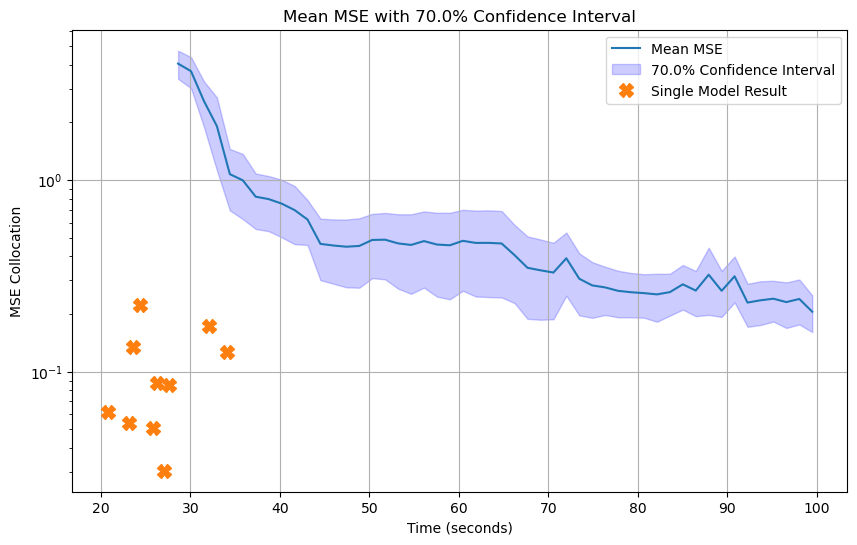

In [39]:
# Plot the mean with confidence intervals
plt.figure(figsize=(10, 6))
plt.plot(times, mean_mse.values, label='Mean MSE')
plt.fill_between(times, lower_bound, upper_bound, color='blue', alpha=0.2, label=f'{confidence*100}% Confidence Interval')

#for i in range(df_single.shape[0]):
plt.plot( df_single.times_elapsed.tolist(), df_single.mse_coll_ode.tolist(), 'X', markersize=10, label=f'Single Model Result')
plt.yscale('log')
plt.xlabel('Time (seconds)')
plt.ylabel('MSE Collocation')
plt.title(f'Mean MSE with {confidence*100}% Confidence Interval')
plt.legend()
plt.grid()
plt.show()

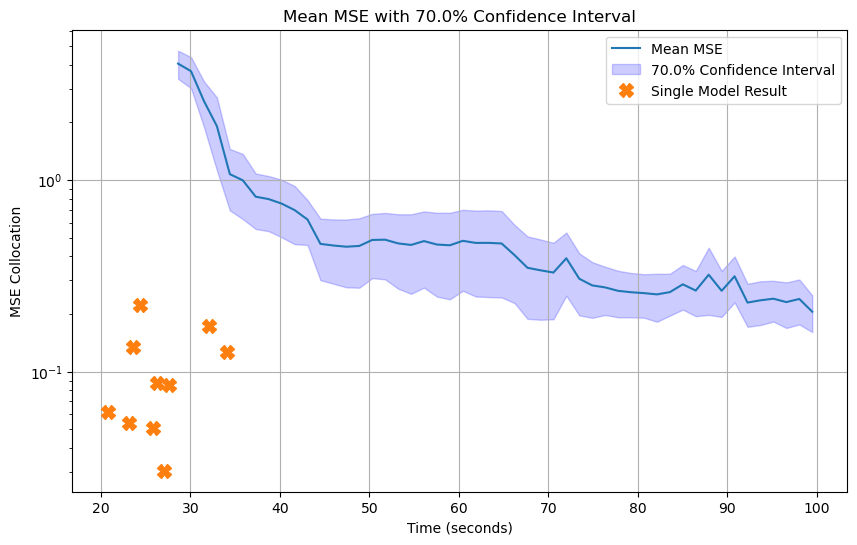

In [40]:
# Plot the mean with confidence intervals
plt.figure(figsize=(10, 6))
plt.plot(times, mean_mse.values, label='Mean MSE')
plt.fill_between(times, lower_bound, upper_bound, color='blue', alpha=0.2, label=f'{confidence*100}% Confidence Interval')

#for i in range(df_single.shape[0]):
plt.plot( df_single.times_elapsed.tolist(), df_single.mse_coll_ode.tolist(), 'X', markersize=10, label=f'Single Model Result')
plt.yscale('log')
plt.xlabel('Time (seconds)')
plt.ylabel('MSE Collocation')
plt.title(f'Mean MSE with {confidence*100}% Confidence Interval')
plt.legend()
plt.grid()
plt.show()

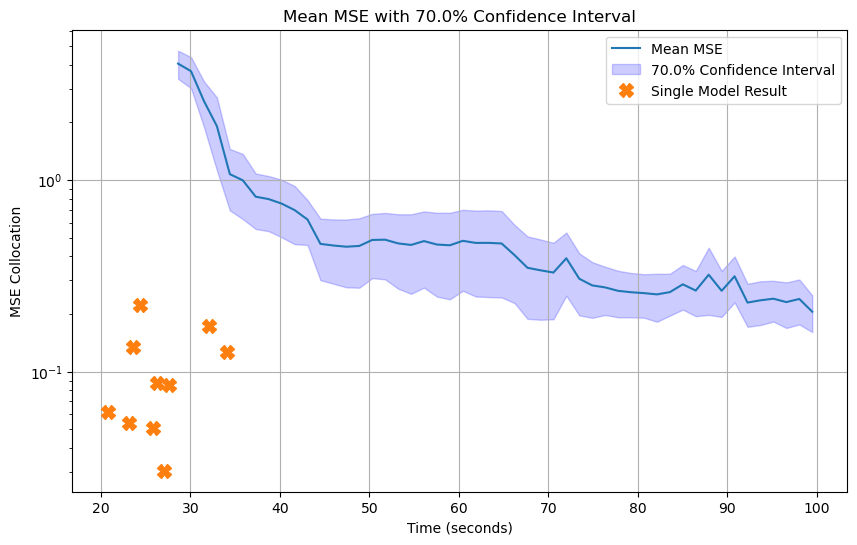

In [41]:
# Plot the mean with confidence intervals
plt.figure(figsize=(10, 6))
plt.plot(times, mean_mse.values, label='Mean MSE')
plt.fill_between(times, lower_bound, upper_bound, color='blue', alpha=0.2, label=f'{confidence*100}% Confidence Interval')

#for i in range(df_single.shape[0]):
plt.plot( df_single.times_elapsed.tolist(), df_single.mse_coll_ode.tolist(), 'X', markersize=10, label=f'Single Model Result')
plt.yscale('log')
plt.xlabel('Time (seconds)')
plt.ylabel('MSE Collocation')
plt.title(f'Mean MSE with {confidence*100}% Confidence Interval')
plt.legend()
plt.grid()
plt.show()

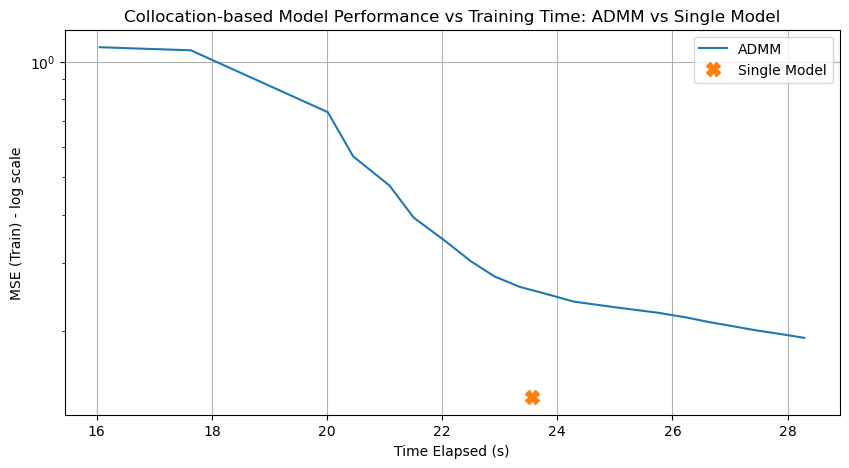

In [28]:
i = 0
plt.figure(figsize=(10, 5))
plt.plot( df.time_elapsed.tolist()[i], df.mse_collocation.tolist()[i], label='ADMM')
#plt.scatter( df.time_elapsed.tolist()[0], df.mse_collocation.tolist()[0])
plt.plot( df_single.times_elapsed.tolist()[i], df_single.mse_coll_ode.tolist()[i], 'X', markersize=10, label='Single Model')
plt.xlabel('Time Elapsed (s)')
plt.ylabel('MSE (Train) - log scale')
plt.yscale('log')
plt.title('Collocation-based Model Performance vs Training Time: ADMM vs Single Model')
plt.legend()
plt.grid()
plt.show()

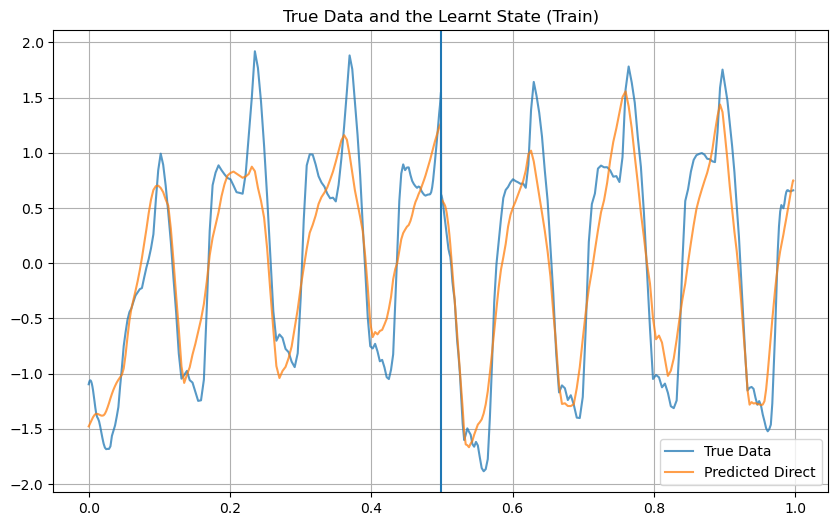

In [29]:
u_model = ode_model.extract_solution().T
plt.figure(figsize=(10, 6))
plt.plot(ts, ys, label='True Data', alpha = 0.75)
plt.plot(ts, u_model, label='Predicted Direct', alpha = 0.75)
plt.axvline(x = np.max(df_train_1['t']))
plt.legend(loc ="lower right")
plt.grid(True)
plt.title("True Data and the Learnt State (Train)")
plt.show()